# 07 — Sample size sweep

Train one model per $N$ in a log-spaced grid, holding the DGP ($T$, $\pi$),
architecture, and training budget fixed.  For each run record:

- **Train NLL** — average per-token cross-entropy on the training set
- **Val NLL** — same on a held-out split of the training set
- **Gen NLL** — same on a fixed test set drawn fresh from the true DGP
- **Reference solution NLLs** — how well each hand-crafted solution does
  under the true distribution, evaluated at the same $N$:
  - *Uniform*: $p(j|i) = 1/K$ (no information used)
  - *Empirical unigram*: $p(j|i) = \hat\pi_j$ (ignores source state)
  - *Empirical bigram*: $\hat T_{ij}$ from MLE on the $N$ samples (optimal given i.i.d. transition data)
  - *Bayes*: true $T_{ij}$ (oracle lower bound)

Results are saved to `data/sample_size_sweep.pt` for plotting in
`08_learning_curves.ipynb`.

**Interpretation:**  
The gen NLL curve vs $N$ is the empirical learning curve of the model.
Comparing it to the reference solution curves shows *which solution the network
has found* at each sample size — a key diagnostic for singular learning theory.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Resolve project root
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt = cwd / "projects" / "markov-chain-learning"
    if (alt / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt
if project_root is None:
    raise RuntimeError("Could not locate project root")

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from markov_chain import sample_sequences
from pytorch_models import MarkovTransformer

DATA_DIR = project_root / "experiments" / "single-chain" / "data"
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


## Load reference DGP

In [3]:
data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
data_cfg = data.get("config", {})
Ts = data["Ts"]
pis = data["pis"]
chain_to_sample = data["chain_to_sample"]

VOCAB = int(data_cfg.get("n_states", Ts.shape[-1]))
MAX_LEN = int(data_cfg.get("L", data_cfg.get("seq_len", 32)))
PAD_ID = int(data_cfg.get("pad_id", -1))

if Ts.shape[0] == 1:
    T_reference = Ts[0]
    pi_reference = pis[0]
else:
    chain_weights = torch.bincount(chain_to_sample, minlength=Ts.shape[0]).float()
    chain_weights /= chain_weights.sum()
    T_reference = (chain_weights[:, None, None] * Ts).sum(0)
    pi_reference = (chain_weights[:, None] * pis).sum(0)

print(f"VOCAB={VOCAB}  MAX_LEN={MAX_LEN}  PAD_ID={PAD_ID}")
print("T_reference:\n", T_reference.numpy().round(3))

VOCAB=5  MAX_LEN=10  PAD_ID=-1
T_reference:
 [[0.148 0.043 0.743 0.051 0.016]
 [0.494 0.137 0.151 0.008 0.21 ]
 [0.264 0.058 0.425 0.053 0.199]
 [0.027 0.19  0.095 0.142 0.546]
 [0.138 0.112 0.353 0.252 0.145]]


## Sweep configuration

In [4]:
# ── Sweep grid ────────────────────────────────────────────────────────────────
N_GRID = [50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]

# ── Training hyperparameters (fixed across all N) ─────────────────────────────
EPOCHS = 200
LR = 3e-3
BATCH_SIZE = 256
VAL_SPLIT = 0.1
SEED = 42

# ── Gen-loss test set (fixed; independent of training data) ───────────────────
N_TEST = 10_000
D_MODEL = VOCAB * 3  # theoretical minimum from Edelman et al. 2024

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}  |  d_model={D_MODEL}")

Device: mps  |  d_model=15


## Build fixed gen-loss test set

In [5]:
rng_test = np.random.default_rng(0)
test_lengths_np = rng_test.integers(low=2, high=MAX_LEN + 1, size=N_TEST)
test_seqs_np = sample_sequences(
    T_reference.numpy(),
    n=N_TEST,
    seq_len=MAX_LEN,
    prior=pi_reference.numpy(),
    rng=0,
)
test_seqs = torch.from_numpy(test_seqs_np).long()  # (N_TEST, MAX_LEN)
test_x_in = test_seqs[:, :-1]  # (N_TEST, MAX_LEN-1)
test_x_tgt = test_seqs[:, 1:]  # (N_TEST, MAX_LEN-1)
test_lengths = torch.from_numpy(test_lengths_np)
test_valid = (torch.arange(MAX_LEN - 1) < (test_lengths.unsqueeze(1) - 1)).numpy()

log_T_ref = torch.log(T_reference.clamp_min(1e-12))
bayes_nll = float(-log_T_ref[test_x_in, test_x_tgt].float().numpy()[test_valid].mean())
uniform_nll = float(np.log(VOCAB))

print(f"Bayes-optimal NLL : {bayes_nll:.6f}")
print(f"Uniform NLL       : {uniform_nll:.6f}")

Bayes-optimal NLL : 1.259612
Uniform NLL       : 1.609438


## Helper functions

In [6]:
class _SeqDS(Dataset):
    def __init__(self, x):
        self.x = x

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i]


def train_model(
    seqs_tensor,
    vocab,
    d_model,
    max_len,
    pad_id,
    epochs,
    lr,
    batch_size,
    val_split,
    seed,
    device,
):
    """Train a fresh MarkovTransformer; return (model, train_losses, val_losses)."""
    torch.manual_seed(seed)
    n_val = max(1, int(len(seqs_tensor) * val_split))
    n_train = len(seqs_tensor) - n_val
    train_ds, val_ds = random_split(
        _SeqDS(seqs_tensor),
        [n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(
        train_ds, batch_size=min(batch_size, n_train), shuffle=True
    )
    val_loader = DataLoader(val_ds, batch_size=min(batch_size, n_val), shuffle=False)

    model = MarkovTransformer(vocab_size=vocab, d_model=d_model, max_len=max_len).to(
        device
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

    def _epoch(loader, training):
        model.train(training)
        total, n_tok = 0.0, 0
        with torch.set_grad_enabled(training):
            for batch in loader:
                batch = batch.to(device)
                x_in = batch[:, :-1]
                x_tgt = batch[:, 1:]
                logits = model(x_in)
                loss = criterion(logits.reshape(-1, vocab), x_tgt.reshape(-1))
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                valid = (x_tgt != pad_id).sum().item()
                total += loss.item() * valid
                n_tok += valid
        return total / max(n_tok, 1)

    best_val, best_state = float("inf"), None
    train_hist, val_hist = [], []
    for _ in range(epochs):
        tl = _epoch(train_loader, True)
        vl = _epoch(val_loader, False)
        train_hist.append(tl)
        val_hist.append(vl)
        if vl < best_val:
            best_val = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    return model.cpu(), train_hist, val_hist


def compute_gen_nll(model, x_in, x_tgt, valid_np, batch_size=512):
    """Mean per-token NLL on the fixed test set."""
    N, L = x_in.shape
    lpm = torch.zeros(N, L)
    model.eval()
    with torch.no_grad():
        for s in range(0, N, batch_size):
            logits = model(x_in[s : s + batch_size])
            lp = torch.log_softmax(logits, dim=-1)
            tgt = x_tgt[s : s + batch_size]
            lpm[s : s + batch_size] = lp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
    return float(-lpm.numpy()[valid_np].mean())


def empirical_bigram(seqs, vocab, pad_id):
    """MLE transition matrix from sequences (add-1e-6 smoothing)."""
    counts = torch.zeros(vocab, vocab)
    for seq in seqs:
        src = seq[:-1]
        dst = seq[1:]
        mask = (src != pad_id) & (dst != pad_id)
        for i, j in zip(src[mask].tolist(), dst[mask].tolist()):
            counts[i, j] += 1
    counts = counts + 1e-6
    return counts / counts.sum(dim=1, keepdim=True)


def empirical_unigram(seqs, vocab, pad_id):
    """Empirical marginal over tokens, expanded to a (vocab, vocab) matrix."""
    counts = torch.zeros(vocab)
    for tok in seqs.flatten():
        if tok.item() != pad_id:
            counts[tok] += 1
    counts = counts + 1e-6
    pi = counts / counts.sum()
    return pi.unsqueeze(0).expand(vocab, -1)


def solution_nll(T_solution, x_in, x_tgt, valid_np):
    """Expected NLL of T_solution evaluated on the fixed test set."""
    log_T = torch.log(T_solution.clamp_min(1e-12))
    lp = log_T[x_in, x_tgt].float().numpy()
    return float(-lp[valid_np].mean())


def model_T(model, vocab):
    """Learned transition matrix via single-token context."""
    all_states = torch.arange(vocab).unsqueeze(1)  # (V, 1)
    model.eval()
    with torch.no_grad():
        logits = model(all_states)  # (V, 1, V)
    return logits[:, 0, :].softmax(dim=-1)  # (V, V)


def kl_rows(P, Q):
    """KL(P[i] || Q[i]) per row, weighted by pi_reference, summed."""
    log_ratio = torch.log(P.clamp_min(1e-12)) - torch.log(Q.clamp_min(1e-12))
    return float((pi_reference[:, None] * P * log_ratio).sum())

## Run sweep

In [ ]:
cfg = dict(vocab_size=VOCAB, d_model=D_MODEL, max_len=MAX_LEN)

records = []
model_dir = DATA_DIR / "sample_size_models"
model_dir.mkdir(parents=True, exist_ok=True)

for N in tqdm(N_GRID, desc="N sweep"):
    # ── Sample N fresh training sequences from the true DGP ───────────────
    seqs_np = sample_sequences(
        T_reference.numpy(),
        n=N,
        seq_len=MAX_LEN,
        prior=pi_reference.numpy(),
        rng=SEED + N,
    )
    seqs = torch.from_numpy(seqs_np).long()

    # ── Reference solutions from this sample ──────────────────────────────
    T_bigram = empirical_bigram(seqs, VOCAB, PAD_ID)
    T_unigram = empirical_unigram(seqs, VOCAB, PAD_ID)
    T_uniform = torch.ones(VOCAB, VOCAB) / VOCAB

    nll_bigram = solution_nll(T_bigram, test_x_in, test_x_tgt, test_valid)
    nll_unigram = solution_nll(T_unigram, test_x_in, test_x_tgt, test_valid)
    nll_uniform = solution_nll(T_uniform, test_x_in, test_x_tgt, test_valid)

    # ── Train model ───────────────────────────────────────────────────────
    m, train_hist, val_hist = train_model(
        seqs,
        VOCAB,
        D_MODEL,
        MAX_LEN,
        PAD_ID,
        EPOCHS,
        LR,
        BATCH_SIZE,
        VAL_SPLIT,
        SEED,
        device,
    )

    # ── Gen NLL on fixed test set ─────────────────────────────────────────
    gen_nll = compute_gen_nll(m, test_x_in, test_x_tgt, test_valid)

    # ── KL divergences on fixed test set (baseline || model) ─────────────
    pi = torch.from_numpy(pi_reference.numpy()).float()
    log_pi = torch.log(pi.clamp_min(1e-12))
    uniform_prob = 1.0 / float(VOCAB)
    log_uniform = torch.log(torch.tensor(uniform_prob, dtype=torch.float32))

    kl_unigram_sum = 0.0
    kl_bigram_sum = 0.0
    kl_uniform_sum = 0.0
    kl_count = 0

    with torch.no_grad():
        for start in range(0, N_TEST, 512):
            logits = m(test_x_in[start : start + 512])
            probs = torch.softmax(logits, dim=-1)

            # Unigram baseline KL(unigram || model)
            kl_uni = (
                pi[None, None, :]
                * (log_pi[None, None, :] - torch.log(probs.clamp_min(1e-12)))
            ).sum(dim=-1)

            # Bigram baseline KL(bigram || model)
            p_bigram = T_reference[test_x_in[start : start + 512]]
            log_p_bigram = torch.log(p_bigram.clamp_min(1e-12))
            kl_bi = (p_bigram * (log_p_bigram - torch.log(probs.clamp_min(1e-12)))).sum(
                dim=-1
            )

            valid_batch = test_valid[start : start + 512]
            kl_unigram_sum += float(kl_uni[valid_batch].sum().item())
            kl_bigram_sum += float(kl_bi[valid_batch].sum().item())

            # Uniform baseline KL(uniform || model)
            kl_uniform = log_uniform - torch.log(probs.clamp_min(1e-12))
            kl_uniform = kl_uniform.sum(dim=-1)
            kl_uniform_sum += float(kl_uniform[valid_batch].sum().item())

            kl_count += int(valid_batch.sum().item())

    gen_kl_unigram = float(kl_unigram_sum / max(1, kl_count))
    gen_kl_bigram = float(kl_bigram_sum / max(1, kl_count))
    gen_kl_uniform = float(kl_uniform_sum / max(1, kl_count))

    # ── KL distances: KL(T_true || T_model) weighted by pi ────────────────
    T_model = model_T(m, VOCAB)
    kl_to_true = kl_rows(T_reference, T_model)
    kl_to_bigram = kl_rows(T_model, T_bigram)
    kl_to_unigram = kl_rows(T_model, T_unigram)
    kl_to_uniform = kl_rows(T_model, T_uniform)

    model_checkpoint_path = model_dir / f"checkpoint_N_{N}.pt"
    torch.save(
        {
            "config": cfg,
            "N": N,
            "model_state_dict": m.state_dict(),
            "train_hist": train_hist,
            "val_hist": val_hist,
            "train_nll": train_hist[-1],
            "val_nll": val_hist[-1],
            "gen_nll": gen_nll,
            "gen_kl_unigram": gen_kl_unigram,
            "gen_kl_bigram": gen_kl_bigram,
            "gen_kl_uniform": gen_kl_uniform,
        },
        model_checkpoint_path,
    )

    records.append(
        dict(
            N=N,
            train_nll=train_hist[-1],
            val_nll=val_hist[-1],
            gen_nll=gen_nll,
            nll_bigram=nll_bigram,
            nll_unigram=nll_unigram,
            nll_uniform=nll_uniform,
            nll_bayes=bayes_nll,
            gen_kl_unigram=gen_kl_unigram,
            gen_kl_bigram=gen_kl_bigram,
            gen_kl_uniform=gen_kl_uniform,
            kl_to_true=kl_to_true,
            kl_to_bigram=kl_to_bigram,
            kl_to_unigram=kl_to_unigram,
            kl_to_uniform=kl_to_uniform,
            train_hist=train_hist,
            val_hist=val_hist,
            T_model=T_model.numpy(),
            checkpoint_path=str(model_checkpoint_path.name),
        )
    )
    tqdm.write(
        f"  N={N:>6}  gen={gen_nll:.4f}  kl_uni={gen_kl_unigram:.4f}  kl_bi={gen_kl_bigram:.4f}  kl_unif={gen_kl_uniform:.4f}"
    )

torch.save(records, DATA_DIR / "sample_size_sweep.pt")
print("Saved:", DATA_DIR / "sample_size_sweep.pt")

N sweep:   0%|          | 0/10 [00:00<?, ?it/s]

  N=    50  gen=1.3196  kl_uni=0.2492  kl_bi=0.0595  kl_unif=2.3216
  N=   100  gen=1.3113  kl_uni=0.2600  kl_bi=0.0518  kl_unif=2.6477
  N=   200  gen=1.2723  kl_uni=0.2254  kl_bi=0.0123  kl_unif=2.1542
  N=   500  gen=1.2687  kl_uni=0.1996  kl_bi=0.0086  kl_unif=1.8708
  N=  1000  gen=1.2671  kl_uni=0.2068  kl_bi=0.0070  kl_unif=2.0629
  N=  2000  gen=1.2625  kl_uni=0.2317  kl_bi=0.0032  kl_unif=2.1644
  N=  5000  gen=1.2614  kl_uni=0.2275  kl_bi=0.0014  kl_unif=2.1604
  N= 10000  gen=1.2605  kl_uni=0.2179  kl_bi=0.0008  kl_unif=2.0939
  N= 20000  gen=1.2599  kl_uni=0.2214  kl_bi=0.0004  kl_unif=2.1234
  N= 50000  gen=1.2600  kl_uni=0.2232  kl_bi=0.0004  kl_unif=2.1432
Saved: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_sweep.pt


## Quick preview

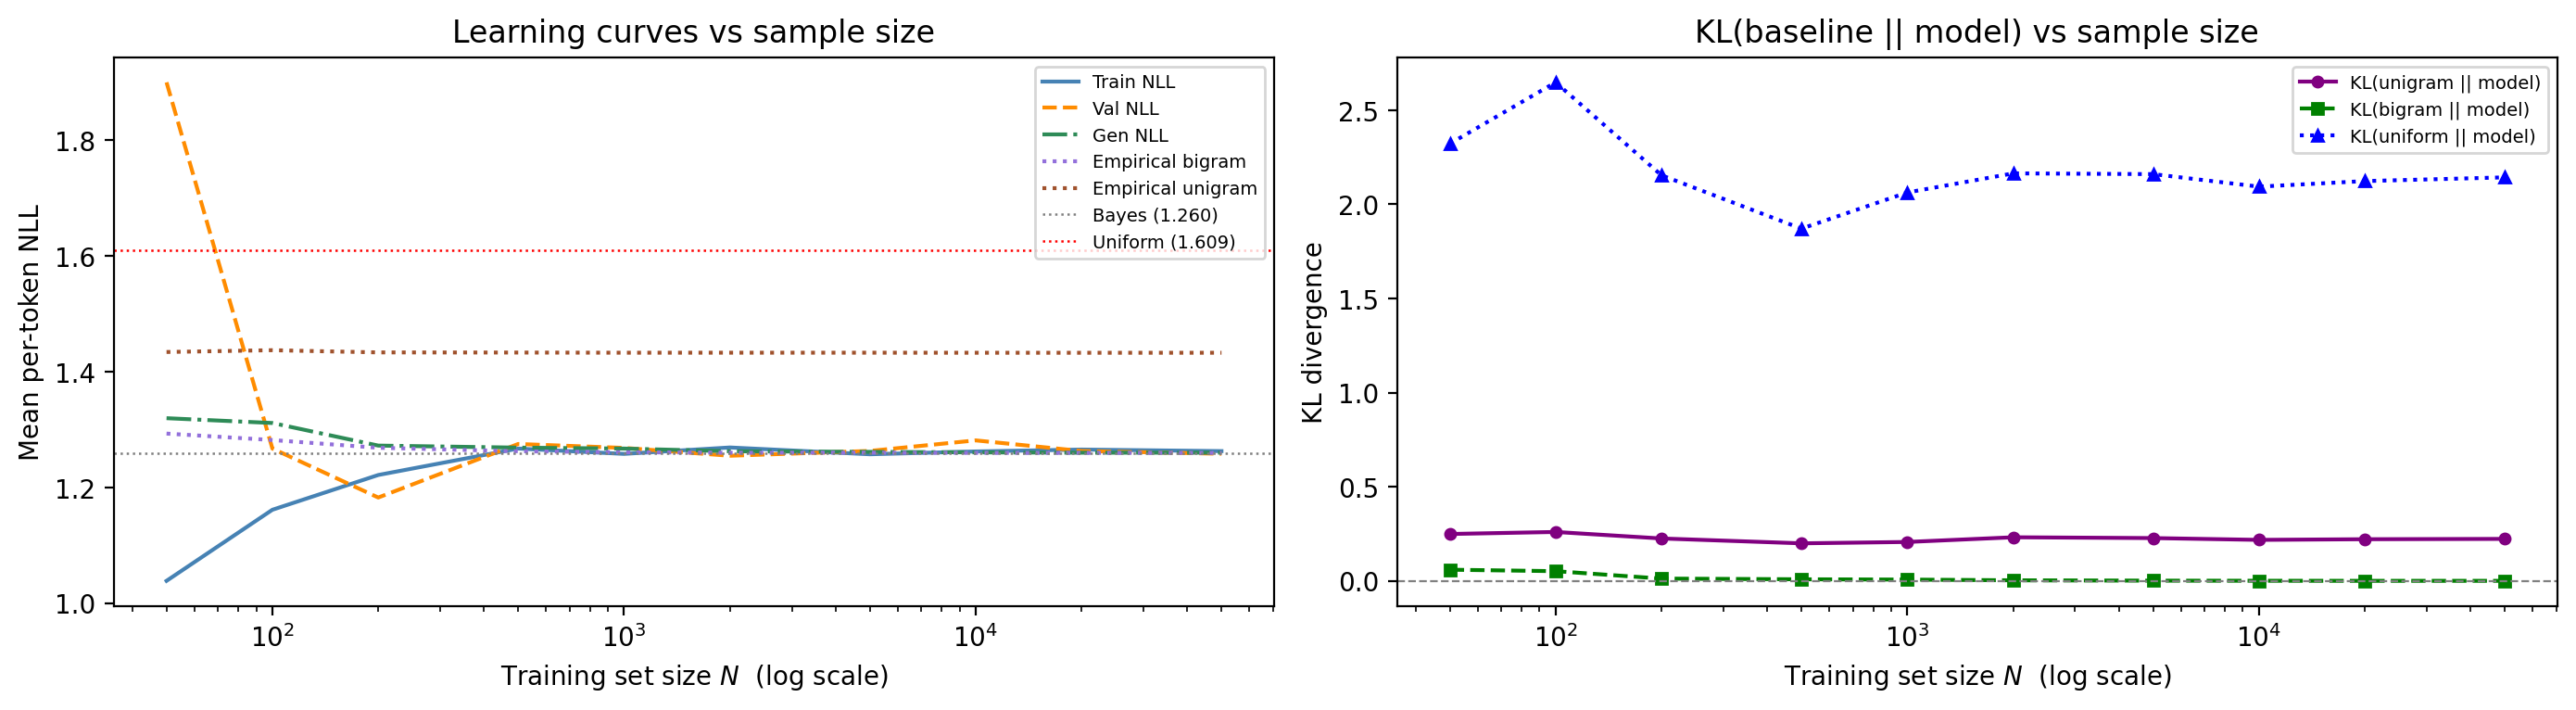

In [9]:
Ns = [r["N"] for r in records]
train_nlls = [r["train_nll"] for r in records]
val_nlls = [r["val_nll"] for r in records]
gen_nlls = [r["gen_nll"] for r in records]
bigram_nlls = [r["nll_bigram"] for r in records]
unigram_nlls = [r["nll_unigram"] for r in records]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1 — NLL vs N
axes[0].semilogx(Ns, train_nlls, label="Train NLL", color="steelblue")
axes[0].semilogx(Ns, val_nlls, label="Val NLL", color="darkorange", linestyle="--")
axes[0].semilogx(Ns, gen_nlls, label="Gen NLL", color="seagreen", linestyle="-.")
axes[0].semilogx(
    Ns, bigram_nlls, label="Empirical bigram", color="mediumpurple", linestyle=":"
)
axes[0].semilogx(
    Ns, unigram_nlls, label="Empirical unigram", color="sienna", linestyle=":"
)
axes[0].axhline(
    bayes_nll,
    color="gray",
    linewidth=0.9,
    linestyle=":",
    label=f"Bayes ({bayes_nll:.3f})",
)
axes[0].axhline(
    uniform_nll,
    color="red",
    linewidth=0.9,
    linestyle=":",
    label=f"Uniform ({uniform_nll:.3f})",
)
axes[0].set_xlabel("Training set size $N$  (log scale)")
axes[0].set_ylabel("Mean per-token NLL")
axes[0].set_title("Learning curves vs sample size")
axes[0].legend(fontsize=7)

# Panel 2 — KL(baseline || model) vs N
gen_kl_unigram_list = [r["gen_kl_unigram"] for r in records]
gen_kl_bigram_list = [r["gen_kl_bigram"] for r in records]
gen_kl_uniform_list = [r["gen_kl_uniform"] for r in records]
axes[1].semilogx(
    Ns,
    gen_kl_unigram_list,
    label="KL(unigram || model)",
    color="purple",
    linestyle="-",
    marker="o",
    markersize=4,
)
axes[1].semilogx(
    Ns,
    gen_kl_bigram_list,
    label="KL(bigram || model)",
    color="green",
    linestyle="--",
    marker="s",
    markersize=4,
)
axes[1].semilogx(
    Ns,
    gen_kl_uniform_list,
    label="KL(uniform || model)",
    color="blue",
    linestyle=":",
    marker="^",
    markersize=4,
)
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Training set size $N$  (log scale)")
axes[1].set_ylabel("KL divergence")
axes[1].set_title("KL(baseline || model) vs sample size")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()